# 01 - Data Acquisition
Liest lokale Rohdaten aus data/raw/ - kein Download.

| Datei | Quelle | Inhalt |
|-------|--------|--------|
| pharmacies_ch.geojson | OpenStreetMap | 1640 Apotheken |
| gemeinden_ch_lv95.geojson | swisstopo 2026 | 2123 Gemeinden |
| plz_ch_lv95.geojson | swisstopo | 4073 PLZ |
| stadtquartiere_zuerich.geojson | Stadt Zuerich OGD | 34 Quartiere ZH |

**Projektion:** LV95 (EPSG:2056)

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import requests
import io
from pathlib import Path

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(parents=True, exist_ok=True)
print('RAW:      ', RAW.resolve())
print('PROCESSED:', PROCESSED.resolve())

RAW:       C:\Projects\pharmacy-accessibility-ch\data\raw
PROCESSED: C:\Projects\pharmacy-accessibility-ch\data\processed


In [2]:
# 1. Apotheken
gdf_pharmacies = gpd.read_file(RAW / 'pharmacies_ch.geojson')
if gdf_pharmacies.crs.to_epsg() != 2056:
    gdf_pharmacies = gdf_pharmacies.to_crs('EPSG:2056')
print('Apotheken:', len(gdf_pharmacies))
print('CRS:      ', gdf_pharmacies.crs)
gdf_pharmacies.head()

Apotheken: 1640
CRS:       EPSG:2056


,osm_id,name,postcode,city,lat,lon,geometry
0,75757805,Apotheke zum Rebstock,8712,Stäfa,47.240975,8.726228,POINT (2697486.196 1233027.824)
1,132405322,Amavita,8180,Bülach,47.520987,8.540215,POINT (2682966.866 1263942.747)
2,244444037,SunStore,,,46.787960,6.620956,POINT (2537565.374 1182192.047)
3,246249851,Medbase Apotheke Zentrum Töss,8406,Winterthur,47.491757,8.706065,POINT (2695509.445 1260881.799)
4,246249855,Adler-Apotheke,8400,Winterthur,47.499028,8.724259,POINT (2696867.076 1261712.399)


In [3]:
# 2. Gemeinden (swisstopo swissBOUNDARIES3D 2026)
gdf_gemeinden = gpd.read_file(RAW / 'gemeinden_ch_lv95.geojson')
print('Gemeinden:       ', len(gdf_gemeinden))
print('CRS:             ', gdf_gemeinden.crs)
print('Einwohner total: ', gdf_gemeinden['einwohnerzahl'].sum())
gdf_gemeinden[['name','bfs_nummer','einwohnerzahl','gem_flaeche','kantonsnummer']].head()

Gemeinden:        2123
CRS:              EPSG:2056
Einwohner total:  9095329


,name,bfs_nummer,einwohnerzahl,gem_flaeche,kantonsnummer
0,Adliswil,131,19893,777.0,1.0
1,Rheinwald,3714,570,13681.0,18.0
2,Grens,5722,391,256.0,22.0
3,Val Terbi,6730,3270,4669.0,26.0
4,Windisch,4123,8153,491.0,19.0


In [4]:
# 3. PLZ-Gebiete
gdf_plz = gpd.read_file(RAW / 'plz_ch_lv95.geojson')
if gdf_plz.crs.to_epsg() != 2056:
    gdf_plz = gdf_plz.to_crs('EPSG:2056')
print('PLZ-Gebiete:', len(gdf_plz))
print('CRS:        ', gdf_plz.crs)
gdf_plz.head()

PLZ-Gebiete: 4073
CRS:         EPSG:2056


,FK_LOCALIT,ZIP_ID,ZIP4,ADDITIONAL,STATUS,INMODIFICA,MODIFIED,SHAPE_AREA,SHAPE_LEN,geometry
0,8743F6EE-56D0-4A68-8616-791AE83F5F6C,3422,6315,02,REAL,FALSE,2023-08-24,10098585.901907,15221.355239,"POLYGON ((2693852.178 1224044.053, 2694495.901..."
1,6C5568FB-C3D7-48B3-A784-3D0552A7D103,4226,7425,00,REAL,FALSE,2022-05-18,3655017.94528,10577.851539,"POLYGON ((2751312.836 1175165.805, 2752182.405..."
2,723E0FE0-5F8D-47A8-BC50-30EA1454ACB6,1330,2087,00,REAL,FALSE,2025-01-21,3707465.4730425,9968.787869,"POLYGON ((2567926.523 1208111.083, 2567927.643..."
3,C61C6D19-4F7C-49F5-A5AB-92E4A8CCEDB0,2387,3963,00,REAL,FALSE,2025-04-15,18472812.2583737,28974.372865,"POLYGON ((2604668.747 1135391.591, 2604765.203..."
4,9A2E9D13-1773-414A-8387-BA5A69C72245,6587,2575,01,REAL,FALSE,2024-04-17,1431062.234648,5878.531407,"POLYGON ((2581047.785 1213553.83, 2580842.643 ..."


In [5]:
# 4. Stadtquartiere Zuerich
# Quelle: Stadt Zuerich OGD - Statistische Quartiere WFS
ZH_URL = (
    'https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere'
    '?service=WFS&version=1.1.0&request=GetFeature'
    '&typename=adm_statistische_quartiere_map&outputFormat=GeoJSON'
)
r = requests.get(ZH_URL, timeout=60)
print('Status:', r.status_code)
gdf_quartiere = gpd.read_file(io.BytesIO(r.content))
if gdf_quartiere.crs and gdf_quartiere.crs.to_epsg() != 2056:
    gdf_quartiere = gdf_quartiere.to_crs('EPSG:2056')
gdf_quartiere.to_file(RAW / 'stadtquartiere_zuerich.geojson', driver='GeoJSON')
print('Stadtquartiere ZH:', len(gdf_quartiere))
print('Spalten:', gdf_quartiere.columns.tolist())
gdf_quartiere.head()

Status: 200


Stadtquartiere ZH: 34
Spalten: ['id', 'geometrie_gdo', 'kname', 'knr', 'objectid', 'qname', 'qnr', 'geometry']


,id,geometrie_gdo,kname,knr,objectid,qname,qnr,geometry
0,adm_statistische_quartiere_map.1,None,Kreis 7,7,1,Hirslanden,73,"POLYGON ((2684457.021 1246514.786, 2684466.328..."
1,adm_statistische_quartiere_map.2,None,Kreis 8,8,2,Weinegg,83,"POLYGON ((2684457.353 1246512.678, 2684458.286..."
2,adm_statistische_quartiere_map.3,None,Kreis 8,8,3,Mühlebach,82,"POLYGON ((2684269.904 1246566.829, 2684271.63 ..."
3,adm_statistische_quartiere_map.4,None,Kreis 8,8,4,Seefeld,81,"POLYGON ((2683794.254 1246609.9, 2683802.14 12..."
4,adm_statistische_quartiere_map.7,None,Kreis 4,4,7,Werd,41,"POLYGON ((2682651.877 1247587.7, 2682650.699 1..."


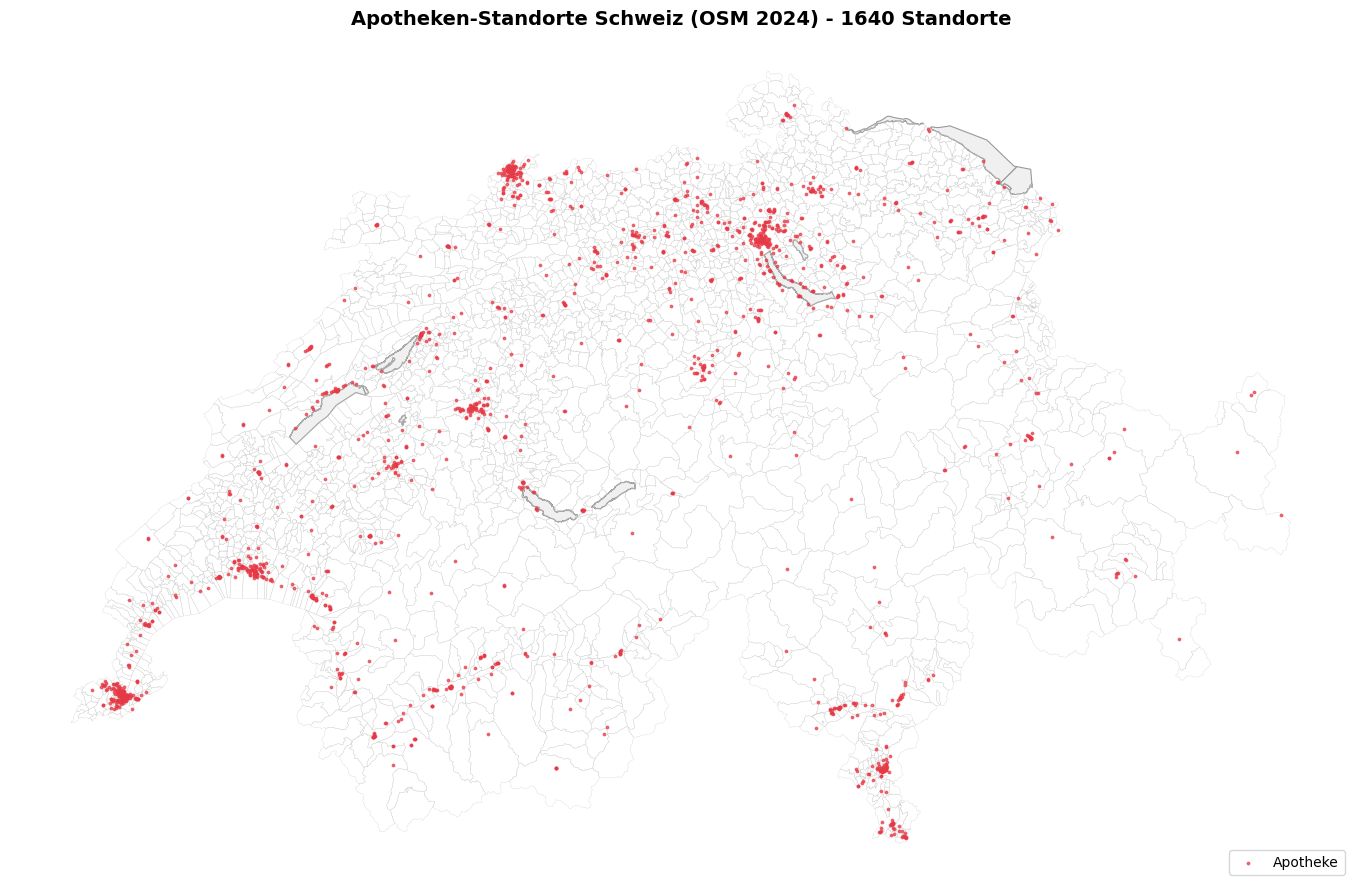

Karte gespeichert: ..\outputs\maps\01_apotheken_uebersicht.png


In [6]:
# 5. Uebersichtskarte
gdf_kantone = gpd.read_file(RAW / 'kantone_ch_lv95.geojson')
fig, ax = plt.subplots(figsize=(14, 9))
gdf_kantone.plot(ax=ax, color='#f0f0f0', edgecolor='#999999', linewidth=0.8)
gdf_gemeinden.plot(ax=ax, color='none', edgecolor='#cccccc', linewidth=0.2)
gdf_pharmacies.plot(ax=ax, color='#e63946', markersize=3, alpha=0.7, label='Apotheke')
ax.set_title('Apotheken-Standorte Schweiz (OSM 2024) - 1640 Standorte', fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend(loc='lower right')
plt.tight_layout()
out = Path('../outputs/maps/01_apotheken_uebersicht.png')
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Karte gespeichert:', out)

In [7]:
# 6. Processed speichern
gdf_pharmacies[['osm_id','name','postcode','city','lat','lon','geometry']].to_file(PROCESSED / 'pharmacies_ch.geojson', driver='GeoJSON')
gdf_gemeinden[['bfs_nummer','name','einwohnerzahl','gem_flaeche','kantonsnummer','geometry']].to_file(PROCESSED / 'gemeinden_ch.geojson', driver='GeoJSON')
gdf_plz.to_file(PROCESSED / 'plz_ch.geojson', driver='GeoJSON')
gdf_quartiere.to_file(PROCESSED / 'stadtquartiere_zuerich.geojson', driver='GeoJSON')
for fname in ['pharmacies_ch.geojson','gemeinden_ch.geojson','plz_ch.geojson','stadtquartiere_zuerich.geojson']:
    p = PROCESSED / fname
    size = str(round(p.stat().st_size/1024)) + ' KB' if p.exists() else 'FEHLT'
    print(f'{fname:<40} {size}')
print('Weiter mit: 02_postgis_analysis.ipynb')

pharmacies_ch.geojson                    423 KB
gemeinden_ch.geojson                     62562 KB
plz_ch.geojson                           115813 KB
stadtquartiere_zuerich.geojson           2153 KB
Weiter mit: 02_postgis_analysis.ipynb
